# Hedging the Carry Book with Futures — Funding-Currency Overlay and Instrument Comparison

Two questions, one notebook:

- **Part A** — does hedging (or cutting) the **funding legs (JPY, CHF)** protect the carry book
  in stress, or is the crash risk spread across the whole book?
- **Part B** — a side-by-side comparison of every hedge instrument in the Bloomberg workbook
  (JY1, SF1, spot+forward replica, TU1, FV1, SPXT/ES1, DX1, UX1) against the committed baseline
  book, with each result decomposed into the instrument's **own return** vs its **variance
  reduction**.

**Data.** The committed baseline book (`cesare/outputs/strategy_returns_daily.csv`, built by the
shared engine) and `FX_Carry_Bloomberg_DATA_clean.xlsx`. The workbook now includes three columns
pulled from the terminal on 2026-08-03 as **static values** (verified in §1 — no live BDH/BDP
formulas): `JY1 Curncy`, `SF1 Curncy` (CME currency futures; the Curncy key matches the existing
`DX1 Curncy` convention) and `SPXT Index` (S&P 500 total return). Nothing else is pulled.

**Instrument-choice notes, stated up front:**

1. **Funding-currency hedge.** With JY1/SF1 present, the listed futures are the primary
   instruments and the **USDJPY (USDCHF) spot + matched-tenor 1M BGN forward** construction is
   the cross-check. The two are the same hedge day to day (corr ≈ 0.94–0.95); their *return
   levels* differ by ~200 bp/yr, which is mostly the generic-series roll-splice artifact — not
   the cross-currency basis — so the replica's own-return level is the earnable one (§1). If the
   futures columns are absent, the replica is the primary and only method.
2. **S&P series.** With SPXT present it is the primary S&P total-return series and ES1 the
   cross-check. Without it, ES1 futures are the TR stand-in (SPX price return understates by
   roughly the ~2%/yr dividend yield).

**Benchmark rule.** Every overlay is judged against the **de-risking control** (cutting exposure
during stress), not against the unhedged book. An overlay only "works" if it beats simple
de-risking net of costs.

In [1]:
import sys, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl
import statsmodels.api as sm

CESARE = Path("../cesare").resolve()
sys.path.insert(0, str(CESARE))
import fx_utils as fx          # shared team engine (shim re-exporting strategy/fx_utils.py)

plt.rcParams["figure.figsize"] = (11, 3.8)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

TEAM_OUT = CESARE / "outputs"
OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
WORKBOOK = Path("FX_Carry_Bloomberg_DATA_clean.xlsx")

def sharpe(r):
    r = pd.Series(r).dropna()
    return r.mean() * fx.ANN_DAYS / (r.std() * np.sqrt(fx.ANN_DAYS))

print("engine:", fx.__file__)

engine: C:\Users\TEMP.CAMPUS.056\Desktop\today's work\FX_Carry_26_Summer_PL-main\FX_Carry_26_Summer_PL-main\cesare\fx_utils.py


## 0. Reconciliation gate

Before any analysis: the committed daily book must reproduce the committed headline stats
(combined net Sharpe **0.466**, G10-only **0.119**). Everything downstream builds on these
committed daily returns — the book is **not** re-derived.

In [2]:
book_csv = pd.read_csv(TEAM_OUT / "strategy_returns_daily.csv", parse_dates=["date"], index_col="date")
all_book = book_csv["ALL_net"].dropna()      # combined book (Part B baseline)
g10_book = book_csv["G10_net"].dropna()      # G10 book (Part A: the funding legs live here)

committed = pd.read_csv(TEAM_OUT / "strategy_summary_stats.csv", index_col=0)
recon = pd.DataFrame({
    "from_daily_csv": [sharpe(all_book), sharpe(g10_book)],
    "committed_stat": [committed.loc["ALL_net", "sharpe"], committed.loc["G10_net", "sharpe"]],
}, index=["ALL_net", "G10_net"])
recon["abs_diff"] = (recon["from_daily_csv"] - recon["committed_stat"]).abs()
print(recon.round(4))
assert (recon["abs_diff"] < 5e-3).all(), "Reconciliation FAILED"
print(f"\nReconciliation PASSED.  ALL_net: {len(all_book)} days "
      f"({all_book.index[0].date()} -> {all_book.index[-1].date()}), G10_net: {len(g10_book)} days")

         from_daily_csv  committed_stat  abs_diff
ALL_net          0.4659          0.4659       0.0
G10_net          0.1191          0.1191       0.0

Reconciliation PASSED.  ALL_net: 5001 days (2007-05-01 -> 2026-06-30), G10_net: 4994 days


### Isolating the funding legs

The committed CSV is the aggregate book only. To cut or flip *one leg* we need the daily
per-currency contribution `w[ccy]·xret[ccy]`, which requires the engine's weights. The books are
rebuilt with the exact committed construction and gated: rebuilt daily returns must equal the
committed CSV to numerical precision, and the per-currency contributions must sum back to the
gross book exactly. This is **reconstruction for attribution, not re-derivation** — the committed
series remains the baseline everywhere.

In [3]:
g10_px = fx.load_wide("g10_fx_spot_forward")
em_px  = fx.load_wide("em_fx_spot_forward")
spots  = fx.spots_usd_per_fx(g10_px, em_px)
carry  = fx.carry_panel(g10_px, em_px, tenor="1M")
xret   = fx.excess_returns(spots, carry)

UNIVERSE_G10 = ["AUD", "CAD", "CHF", "EUR", "GBP", "JPY", "NOK", "NZD", "SEK"]
UNIVERSE_ALL = [c for c in xret.columns if c not in ("HKD", "DKK", "CNY")]
hs_out, hs_pts = fx.forward_halfspreads(tenor="1M")

def build_book(universe, n_buckets, name):
    w_unit = fx.carry_portfolio(carry, xret, n_buckets=n_buckets, universe=universe)
    w_vt = fx.vol_target_weights(w_unit, xret, target=0.10)
    gross = fx.portfolio_returns(w_vt, xret, f"{name}_gross")
    net = (gross - fx.roundtrip_cost(w_vt, hs_out, hs_pts)).rename(f"{name}_net")
    return gross, net, w_vt

g10_gross_rb, g10_net_rb, w_g10 = build_book(UNIVERSE_G10, 3, "G10")
all_gross_rb, all_net_rb, w_all = build_book(UNIVERSE_ALL, 5, "ALL")

for nm, rb, cm in [("G10", g10_net_rb, g10_book), ("ALL", all_net_rb, all_book)]:
    gap = (rb.reindex(cm.index) - cm).abs().max()
    print(f"{nm}: max |rebuilt - committed| daily return = {gap:.2e}")
    assert gap < 1e-8, f"{nm} rebuild does not match the committed book"

# contributions must reconstruct the gross book exactly
for nm, w, gr, cal in [("G10", w_g10, g10_gross_rb, g10_book.index), ("ALL", w_all, all_gross_rb, all_book.index)]:
    contrib = (w * xret[w.columns]).loc[cal[0]:cal[-1]]
    gap = (contrib.sum(axis=1) - gr.loc[cal[0]:cal[-1]]).abs().max()
    print(f"{nm}: max |sum(contrib) - gross| = {gap:.1e}")
    assert gap < 1e-10

contrib_jpy_g10 = (w_g10["JPY"] * xret["JPY"]).reindex(g10_book.index).fillna(0.0)
contrib_jpy_all = (w_all["JPY"] * xret["JPY"]).reindex(all_book.index).fillna(0.0)
for nm, w, c, cal in [("G10", w_g10, contrib_jpy_g10, g10_book.index),
                      ("ALL", w_all, contrib_jpy_all, all_book.index)]:
    wj = w["JPY"].reindex(cal)
    print(f"{nm} JPY leg: mean weight {wj.mean():+.3f}, short {100*(wj<0).mean():.0f}% of days, "
          f"contribution {c.mean()*fx.ANN_DAYS:+.2%}/yr")

G10: max |rebuilt - committed| daily return = 2.50e-16
ALL: max |rebuilt - committed| daily return = 9.24e-16
G10: max |sum(contrib) - gross| = 0.0e+00
ALL: max |sum(contrib) - gross| = 0.0e+00
G10 JPY leg: mean weight -0.373, short 79% of days, contribution +1.88%/yr
ALL JPY leg: mean weight -0.267, short 97% of days, contribution +1.25%/yr


## 1. Workbook load and data hygiene

The workbook stores each ticker as an independent block (`NAME [TICKER] FIELDS` header, own date
column), on a **padded 5,087-row calendar** where non-trading days are carried forward. Three
hygiene rules, per the data audit:

- Parse **per block**, never as one rectangular sheet — blocks are not row-aligned
  (`Funding_OIS_RateVol` has a 7,121-row MOVE block beside 5,087-row blocks; not used here, but a
  bulk `read_excel` would silently mis-join it).
- Missing values are the **literal string `"#N/A N/A"`**, not blanks — the parser nulls them
  (count printed below). Skipping this poisons returns and biases every beta toward zero.
- **Inner-join each instrument to the book's trading calendar, then drop zero-change (stale)
  rows** — carried-forward prices produce fake zero returns that also bias betas toward zero.
  Row counts are printed before and after each step.

The 2026-08-03 additions (JY1, SF1, SPXT) are detected below with a one-line load confirmation
each, and gated to be **static numeric values** — a Bloomberg pull saved as BDH/BDP formulas
would go stale off the terminal, so formula cells hard-stop the notebook.

In [4]:
NA_LITERAL = "#N/A N/A"
LABEL_RE = re.compile(r"^(.*?)\s+\[(.*?)\]\s+(.*)$")
na_seen = {"n": 0}

def parse_bbg_tab(xlsx, tab):
    """Parse one workbook sheet block-by-block -> {(ticker, field): Series}."""
    wb = openpyxl.load_workbook(xlsx, read_only=True, data_only=True)
    grid = [list(r) for r in wb[tab].iter_rows(values_only=True)]
    out = {}
    for ri, row in enumerate(grid):
        for ci, cell in enumerate(row):
            if not isinstance(cell, str):
                continue
            m = LABEL_RE.match(cell.strip())
            if not m:
                continue
            tick = m.group(2).strip()
            fields = [f.strip() for f in m.group(3).split(",")]
            dates, cols = [], [[] for _ in fields]
            for rr in range(ri + 1, len(grid)):
                r2 = grid[rr]
                d = r2[ci] if ci < len(r2) else None
                if d is None or not hasattr(d, "year"):
                    continue
                dates.append(pd.Timestamp(d))
                for k in range(len(fields)):
                    c = ci + 1 + k
                    v = r2[c] if c < len(r2) else None
                    if isinstance(v, str) and v.strip() == NA_LITERAL:
                        na_seen["n"] += 1
                        v = None
                    cols[k].append(v if isinstance(v, (int, float)) else np.nan)
            if dates:
                idx = pd.DatetimeIndex(dates)
                for k, f in enumerate(fields):
                    out[(tick, f)] = pd.Series(cols[k], index=idx, dtype="float64").sort_index()
    wb.close()
    return out

TABS = {t: parse_bbg_tab(WORKBOOK, t) for t in
        ["FX_Spot", "FX_Fwd_1M", "FXVol_Indices", "Dollar", "Duration", "Equity", "EquityVol"]}

def S(tab, tick, fld="PX_LAST"):
    return TABS[tab][(tick, fld)]

print(f'literal "{NA_LITERAL}" cells nulled while parsing: {na_seen["n"]}')

# ---- optional columns: JY1 (JPY future), SF1 (CHF future), SPXT/SPTR (S&P TR) ----
# Pulled from the terminal 2026-08-03 under the Curncy key (matching DX1 Curncy; the
# Comdty key resolves to dead/unrelated contracts). Detect anywhere in the workbook;
# the notebook never fails if they are absent.
def find_optional(roots, field="PX_LAST"):
    """(ticker, series) for the first block whose ticker root matches one of
    `roots` (e.g. 'JY1' matches 'JY1 Curncy'), searching every sheet; None if absent."""
    roots = tuple(r.upper() for r in roots)
    def scan():
        for d in TABS.values():
            for (tick, fld), s in d.items():
                if fld == field and tick.split()[0].upper() in roots:
                    return tick, s
        return None
    hit = scan()
    if hit is None:      # parse any sheets not yet loaded (cached), then look again
        wb = openpyxl.load_workbook(WORKBOOK, read_only=True)
        extra = [t for t in wb.sheetnames if t not in TABS and t != "READ_ME"]
        wb.close()
        for t in extra:
            TABS[t] = parse_bbg_tab(WORKBOOK, t)
        hit = scan()
    return hit

jy1_hit  = find_optional(("JY1",))
sf1_hit  = find_optional(("SF1",))
sptr_hit = find_optional(("SPXT", "SPTR"))
for nm, hit in [("JY1 (JPY future)", jy1_hit), ("SF1 (CHF future)", sf1_hit),
                ("SPXT/SPTR (S&P total return)", sptr_hit)]:
    if hit is None:
        print(f"optional column {nm}: not present")
    else:
        s = hit[1]
        v = s.dropna()
        print(f"optional column {nm}: LOADED as {hit[0]} -- {len(s)} rows, "
              f"{v.index[0].date()} -> {v.index[-1].date()}, {100*s.isna().mean():.2f}% missing")

# ---- portability gate: the new columns must be STATIC VALUES, not Bloomberg formulas.
# Loading with data_only=False exposes formulas as '=...' strings (data_type 'f');
# BDH/BDP/BDS/RTD cells would break the workbook on any machine without a terminal.
def assert_static(root, sheet):
    wb = openpyxl.load_workbook(WORKBOOK, data_only=False)
    ws = wb[sheet]
    hdr = next((c for row in ws.iter_rows(min_row=1, max_row=5) for c in row
                if isinstance(c.value, str) and f"[{root} " in c.value), None)
    if hdr is None:
        wb.close(); return
    bad, dtypes, samples = 0, set(), []
    for r in range(hdr.row + 1, ws.max_row + 1):
        c = ws.cell(row=r, column=hdr.column + 1)
        if c.value is None:
            continue
        dtypes.add(f"{c.data_type}:{type(c.value).__name__}")
        if c.data_type == "f" or (isinstance(c.value, str) and
                ("=" in str(c.value)[:2] or any(k in str(c.value).upper() for k in ("BDH", "BDP", "BDS", "RTD")))):
            bad += 1
        elif len(samples) < 5 and c.data_type == "n":
            samples.append(c.value)
    wb.close()
    print(f"  static check {root}: dtypes {sorted(dtypes)}, formula cells {bad}, sample {samples}")
    assert bad == 0, f"{root} contains {bad} Bloomberg formula cells - workbook is NOT portable, STOP"

for root, sheet, hit in [("JY1", "Dollar", jy1_hit), ("SF1", "Dollar", sf1_hit), ("SPXT", "Equity", sptr_hit)]:
    if hit is not None:
        assert_static(root, sheet)

literal "#N/A N/A" cells nulled while parsing: 4369
optional column JY1 (JPY future): LOADED as JY1 Curncy -- 5087 rows, 2007-01-02 -> 2026-06-30, 0.02% missing
optional column SF1 (CHF future): LOADED as SF1 Curncy -- 5087 rows, 2007-01-02 -> 2026-06-30, 0.02% missing
optional column SPXT/SPTR (S&P total return): LOADED as SPXT Index -- 5087 rows, 2007-01-03 -> 2026-06-30, 0.04% missing


  static check JY1: dtypes ['n:float', 'n:int', 's:str'], formula cells 0, sample [85, 84.63, 84.79, 85.11, 85.01]


  static check SF1: dtypes ['n:float', 'n:int', 's:str'], formula cells 0, sample [83.06, 82.14, 81.64, 81.45, 81.38]


  static check SPXT: dtypes ['n:float', 'n:int', 's:str'], formula cells 0, sample [2183.92, 2186.6, 2173.29, 2178.8, 2177.68]


In [5]:
CAL = all_book.index      # the book's trading calendar (5,001 days)

def clean_ret(level, name, cal=None):
    """Inner-join a price level to the book calendar, drop stale (zero-change) rows."""
    cal = CAL if cal is None else cal
    lvl = level.dropna()
    raw_n = len(lvl)
    lvl = lvl[lvl.index.isin(cal)]
    joined_n = len(lvl)
    r = lvl.pct_change()
    stale = int((r == 0.0).sum())
    r = r[r != 0.0].dropna()
    print(f"  {name:14s} raw {raw_n:5d} -> joined {joined_n:5d} -> clean {len(r):5d}  ({stale} stale zero-change rows dropped)")
    return r.rename(name)

print("row counts: workbook calendar -> book calendar -> after stale-row drop")
r_dx1  = clean_ret(S("Dollar",   "DX1 Curncy"),   "DX1")
r_tu1  = clean_ret(S("Duration", "TU1 Comdty"),   "TU1")
r_fv1  = clean_ret(S("Duration", "FV1 Comdty"),   "FV1")
r_es1  = clean_ret(S("Equity",   "ES1 Index"),    "ES1")
r_ux1  = clean_ret(S("EquityVol","UX1 Index"),    "UX1_generic")
r_vixtr= clean_ret(S("EquityVol","SPVXSTR Index"),"UX1_SPVXSTR")
r_mxef = clean_ret(S("Equity",   "MXEF Index"),   "MXEF")

row counts: workbook calendar -> book calendar -> after stale-row drop
  DX1            raw  5087 -> joined  4994 -> clean  4843  (150 stale zero-change rows dropped)
  TU1            raw  5087 -> joined  4994 -> clean  4561  (432 stale zero-change rows dropped)
  FV1            raw  5087 -> joined  4994 -> clean  4747  (246 stale zero-change rows dropped)
  ES1            raw  5087 -> joined  4994 -> clean  4773  (220 stale zero-change rows dropped)
  UX1_generic    raw  5087 -> joined  4994 -> clean  4728  (265 stale zero-change rows dropped)
  UX1_SPVXSTR    raw  5087 -> joined  4994 -> clean  4815  (178 stale zero-change rows dropped)
  MXEF           raw  5087 -> joined  4994 -> clean  4987  (6 stale zero-change rows dropped)


### The funding-currency instruments: spot + 1M forward replica, and listed futures

The forward-based construction (the original primary, now the cross-check): from USDJPY spot and
the 1M BGN forward points (scale /100, the engine's `FWD_SCALE`),

daily return = −Δln(USDJPY) + forward-implied carry (lagged) / 252

i.e. the excess return of holding JPY long one month forward — a JPY futures position up to the
**cross-currency basis**. Sanity check: it must be nearly identical to the engine's `xret["JPY"]`.
The same construction is applied to CHF when the SF1 cross-check runs.

In [6]:
FWD_SCALE_LOCAL = {"JPY": 1e2, "CHF": 1e4}    # engine FWD_SCALE convention

def fwd_replica(ccy, tick_spot, tick_fwd):
    """Long-FX excess return via USD/FX spot + 1M BGN forward (futures replica)."""
    spot = S("FX_Spot", tick_spot).dropna()
    pts  = S("FX_Fwd_1M", tick_fwd).dropna()
    px = pd.concat([spot.rename("S"), pts.rename("pts")], axis=1).dropna()
    raw_n = len(px)
    px = px[px.index.isin(CAL)]
    F = px["S"] + px["pts"] / FWD_SCALE_LOCAL[ccy]
    carry_ann = np.log(F / px["S"]) * 12      # FX-per-USD quote: long-FX carry = ln(F/S)*12
    r = (-np.log(px["S"]).diff() + carry_ann.shift(1) / fx.ANN_DAYS)
    stale = int((px["S"].diff() == 0.0).sum())
    r = r[px["S"].diff() != 0.0].dropna().rename(f"{ccy}_fwd")
    print(f"  {ccy}_fwd        raw {raw_n:5d} -> joined {len(px):5d} -> clean {len(r):5d}  ({stale} stale zero-change rows dropped)")
    return r

r_jpyfwd = fwd_replica("JPY", "USDJPY Curncy", "USDJPY1M BGN Curncy")

cmn = r_jpyfwd.index.intersection(xret.index)
cc = np.corrcoef(r_jpyfwd.loc[cmn], xret["JPY"].loc[cmn])[0, 1]
print(f"corr(replica, engine xret[JPY]) = {cc:.4f}   "
      f"ann return: replica {r_jpyfwd.mean()*252:+.2%}, engine {xret['JPY'].loc[cmn].mean()*252:+.2%}")
assert cc > 0.99, "JPY replica does not track the engine's JPY excess return"

  JPY_fwd        raw  5087 -> joined  4994 -> clean  4958  (35 stale zero-change rows dropped)
corr(replica, engine xret[JPY]) = 0.9998   ann return: replica -3.46%, engine -3.55%


### Cross-check: listed JPY / CHF futures (JY1 / SF1) vs the forward replica

`JY1 Curncy` / `SF1 Curncy` (CME currency futures, USD-per-FX quotes, pulled 2026-08-03 as static
values) are now in the workbook, so the funding hedge can be run on the **real futures**, with the
spot+forward construction retained as the cross-check. What "landing close" should mean here, and
what it does mean in the data:

- **Day-to-day the two are the same hedge**: daily return correlation ≈ 0.94 (JPY) / 0.95 (CHF),
  with the residual mostly roll-date and close-timing noise.
- **In return levels they are NOT within cross-currency basis of each other**: the futures series
  out-earns the replica by ~200+ bp/yr, an order of magnitude more than the JPY/CHF basis (tens of
  bp). The excess is the **roll-splice artifact of generic front-month series** — the contango
  jump at each quarterly contract switch is spliced into the price history but is not earned by an
  investor who rolls at market prices — plus the 1M-vs-quarterly tenor mismatch. Same mechanism as
  UX1, milder dose.
- Consequently the **replica's own-return level is the honest, earnable one**; the futures series
  is used for hedge *timing* properties, and any verdict that flips only because of the futures'
  extra measured return is flagged as artifact-driven.

If the columns are absent (pre-pull workbook), the replica is the primary and only method and this
cell says so; nothing downstream fails.

In [7]:
def futures_crosscheck(ccy, hit, replica):
    """Clean futures returns + compare vs the forward replica. None if the column is absent."""
    if hit is None:
        print(f"{ccy}: no listed future in the workbook -> spot+forward replica is the primary and only method.")
        return None
    tick, level = hit
    r_fut = clean_ret(level, f"{ccy}_fut")          # USD-per-FX quote: pct change = long-FX return
    cmn = r_fut.index.intersection(replica.index)
    cc = np.corrcoef(r_fut.loc[cmn], replica.loc[cmn])[0, 1]
    gap_ann = (r_fut.loc[cmn].mean() - replica.loc[cmn].mean()) * fx.ANN_DAYS
    def hedged_sr(x):
        idx = all_book.index.intersection(x.index)
        b, xi = all_book.loc[idx], x.loc[idx]
        h = b.cov(xi) / xi.var()
        return sharpe(b - h * xi)
    print(f"{ccy} cross-check vs {tick}: corr(futures, forward replica) = {cc:.4f}")
    print(f"   ann return gap (futures - forward) = {gap_ann*1e4:+.0f} bp/yr  (basis + roll-splice, see note)")
    print(f"   hedged Sharpe at each h*: futures {hedged_sr(r_fut):.4f} vs forward {hedged_sr(replica):.4f}")
    return r_fut

r_jy1 = futures_crosscheck("JPY", jy1_hit, r_jpyfwd)

if sf1_hit is not None:
    r_chffwd = fwd_replica("CHF", "USDCHF Curncy", "USDCHF1M BGN Curncy")
    r_sf1 = futures_crosscheck("CHF", sf1_hit, r_chffwd)
else:
    r_sf1 = None
    print("CHF: no listed future in the workbook -> no CHF cross-check needed "
          "(the funding-hedge analysis runs on JPY, the dominant funding leg).")

if r_jy1 is not None:
    print("\nNOTE on the return gap: the JPY/CHF cross-currency basis runs in the TENS of bp/yr,")
    print("so a ~200 bp/yr gap cannot be basis alone. The bulk is the quarterly ROLL-SPLICE")
    print("artifact of generic front-month series (the contango jump at each contract switch is")
    print("spliced into the price history but is not earned by a rolling long) plus the 1M-vs-")
    print("quarterly tenor mismatch -- the same mechanism as UX1, in milder form. The ~0.94-0.95")
    print("daily correlation says futures and replica are the SAME hedge day to day; the")
    print("replica's own-return level is the earnable one. Futures-based Sharpes that lean on")
    print("the extra 'return' inherit the artifact -- flagged below wherever it moves a verdict.")

  JPY_fut        raw  5086 -> joined  4994 -> clean  4794  (199 stale zero-change rows dropped)
JPY cross-check vs JY1 Curncy: corr(futures, forward replica) = 0.9372
   ann return gap (futures - forward) = +233 bp/yr  (basis + roll-splice, see note)
   hedged Sharpe at each h*: futures 0.4319 vs forward 0.3112
  CHF_fwd        raw  5087 -> joined  4994 -> clean  4945  (48 stale zero-change rows dropped)
  CHF_fut        raw  5086 -> joined  4994 -> clean  4779  (214 stale zero-change rows dropped)
CHF cross-check vs SF1 Curncy: corr(futures, forward replica) = 0.9518
   ann return gap (futures - forward) = +207 bp/yr  (basis + roll-splice, see note)
   hedged Sharpe at each h*: futures 0.5762 vs forward 0.4694

NOTE on the return gap: the JPY/CHF cross-currency basis runs in the TENS of bp/yr,
so a ~200 bp/yr gap cannot be basis alone. The bulk is the quarterly ROLL-SPLICE
artifact of generic front-month series (the contango jump at each contract switch is
spliced into the price histo

# Part A — Funding-currency hedge (JPY primary, CHF alongside)

Part A runs on the **G10 book** (net Sharpe 0.119): the funding legs are a G10 phenomenon, and
the audit's reference results for this test (de-risk ≈ 0.217, stress-replacement short ≈ 0.296)
reproduce exactly on the G10 book. The combined book is shown as a cross-check at the end.

The G10 book is short JPY ~79% of days (mean weight −0.37) — the carry sort funds out of the
low-yielders (CHF is the other structural short). So a *static* hedge ratio on the JPY leg is
just position sizing: it scales a leg the signal deliberately put on. §A.1 runs it as a
reference line only; §A.2 is the real test, with the funding legs cut via the **listed JY1/SF1
futures** and the spot+forward synthetic as cross-check.

## A.1 Static reference: scaling the JPY leg (position sizing, not a hedge)

`return(h) = book − h · contrib_JPY`, h from 0 (baseline) to 1 (JPY leg fully removed).

0.0    0.119
0.2    0.089
0.4    0.057
0.6    0.023
0.8   -0.012
1.0   -0.048


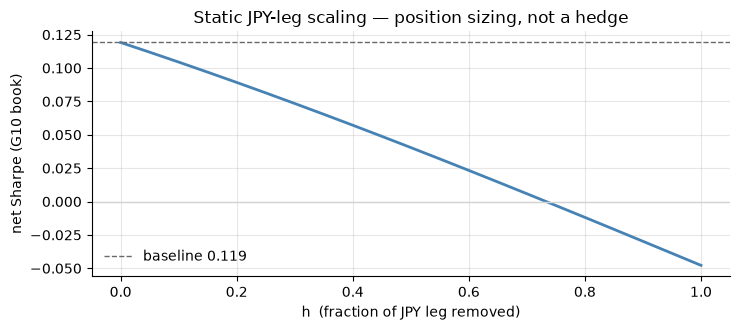

In [8]:
hs = np.arange(0.0, 1.0001, 0.05)
sweep = pd.Series({h: sharpe(g10_book - h * contrib_jpy_g10) for h in hs})
print(sweep.round(3).iloc[::4].to_string())

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(sweep.index, sweep.values, color="steelblue", lw=2)
ax.axhline(sweep.loc[0.0], color="dimgray", ls="--", lw=1, label=f"baseline {sweep.loc[0.0]:.3f}")
ax.axhline(0, color="lightgray", lw=1)
ax.set_xlabel("h  (fraction of JPY leg removed)")
ax.set_ylabel("net Sharpe (G10 book)")
ax.set_title("Static JPY-leg scaling — position sizing, not a hedge")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

> Sharpe falls **monotonically** from 0.119 at h=0 to about −0.05 with the leg fully removed. No
> surprise: the short-JPY leg has been the G10 book's single best earner (+1.9%/yr contribution).
> Statically shrinking it just sheds compensated exposure — this line is a sizing exercise and
> proves nothing about hedging. The real question is *conditional*: does the JPY leg cause the
> stress losses?

## A.2 Dynamic test: cut or flip the funding legs when a stress trigger is ON

**Trigger** — G7 FX implied vol (JPMVXYG7, `FXVol_Indices` sheet) z-score in its top quintile,
lagged one day so it is tradeable. Two constructions were tested:

- **Primary (used below): 252-day rolling z-score, ON when z ≥ 0.8416** — the standard-normal
  top-quintile cutoff. ON 20.9% of days, i.e. an actual quintile of the sample, and it reproduces
  the audit's reference results exactly (whole-book de-risk 0.217, stress-replacement MXEF short
  0.296).
- *Literal expanding variant* (expanding z, expanding 80th-percentile threshold): shown as
  robustness. It triggers on only ~5% of days — the 2008–2012 vol regime dominates the expanding
  distribution and the threshold never comes back down — and does not match the reference numbers.

**Scenarios** (overlay trading costs ignored — futures/forward half-spreads are ~1–2 bp and the
trigger flips rarely; the book side is net of FX costs):

- (a) baseline book, no overlay
- (b) whole-book de-risk: exposure to zero while the trigger is ON
- (c) JPY-leg de-risk: the funding leg neutralised during stress with an offsetting **JY1
  futures** position (the leg is short, so the hedge is long JY1), with the spot+forward
  synthetic as the (c-x) cross-check row; (c') flips the leg via a double-size JY1 position
- (e) CHF-leg de-risk via **SF1 futures**, same design, (e-x) synthetic cross-check;
  (f) both funding legs cut at once
- (d) stress-replacement short: book to zero **and** a vol-matched MXEF (or DX1) short while ON

When the JY1/SF1 columns are absent the (c)/(c') rows fall back to the spot+forward synthetic
and the (e)/(f) rows are skipped.

primary trigger ON 20.9% of days (1043 days) | literal expanding variant ON 5.4%


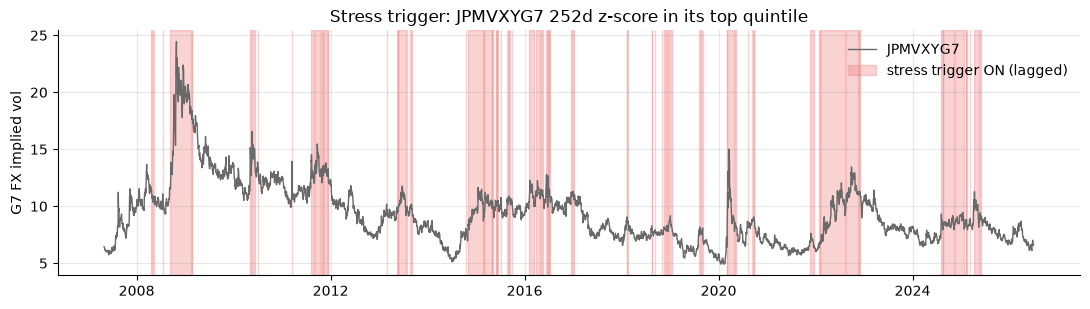

In [9]:
def stress_trigger(cal, kind="rolling"):
    v = S("FXVol_Indices", "JPMVXYG7 Index").dropna()
    v = v[v.index.isin(cal)]
    if kind == "rolling":
        z = (v - v.rolling(252, min_periods=252).mean()) / v.rolling(252, min_periods=252).std()
        raw = z >= 0.8416                      # N(0,1) top-quintile cutoff
    else:                                      # literal expanding construction
        z = (v - v.expanding(252).mean()) / v.expanding(252).std()
        raw = z >= z.expanding(252).quantile(0.80)
    return raw.shift(1).reindex(cal).fillna(False).astype(bool), v, z

trig_g10, vol_g10, z_g10 = stress_trigger(g10_book.index, "rolling")
trig_g10_exp, _, _ = stress_trigger(g10_book.index, "expanding")
print(f"primary trigger ON {trig_g10.mean():.1%} of days ({trig_g10.sum()} days) | "
      f"literal expanding variant ON {trig_g10_exp.mean():.1%}")

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(vol_g10.index, vol_g10.values, color="dimgray", lw=1, label="JPMVXYG7")
ax.fill_between(trig_g10.index, 0, 1, where=trig_g10.values,
                transform=ax.get_xaxis_transform(), color="lightcoral", alpha=0.35,
                label="stress trigger ON (lagged)")
ax.set_ylabel("G7 FX implied vol")
ax.set_title("Stress trigger: JPMVXYG7 252d z-score in its top quintile")
ax.legend(frameon=False, loc="upper right")
plt.tight_layout(); plt.show()

In [10]:
def stress_scenarios(book, trig, w, label):
    """Part A scenario table. Funding legs are cut with LISTED FUTURES (JY1/SF1) when the
    workbook has them, with the spot+forward synthetic kept as a cross-check row; if the
    futures columns are absent the synthetic is the primary (and only) method."""
    vm_mx = book.std() / r_mxef.std()
    vm_dx = book.std() / r_dx1.std()
    x_mx = r_mxef.reindex(book.index).fillna(0.0)
    x_dx = r_dx1.reindex(book.index).fillna(0.0)

    def leg_cut(ccy, r_inst, mult=1.0):
        """Neutralise a funding leg during stress: book - trig * mult * w[ccy] * r_inst."""
        w_d = w[ccy].reindex(book.index).fillna(0.0)
        x = r_inst.reindex(book.index).fillna(0.0)
        return book - trig * mult * (w_d * x)

    scen = {"(a) baseline": book,
            "(b) whole-book de-risk": book * (~trig)}
    if r_jy1 is not None:
        scen["(c) JPY-leg cut via JY1 future"] = leg_cut("JPY", r_jy1)
        scen["(c-x) JPY-leg cut, spot+fwd cross-check"] = leg_cut("JPY", xret["JPY"])
        scen["(c') JPY-leg flip via JY1 future"] = leg_cut("JPY", r_jy1, mult=2.0)
    else:
        scen["(c) JPY-leg cut in stress"] = leg_cut("JPY", xret["JPY"])
        scen["(c') JPY-leg flip in stress"] = leg_cut("JPY", xret["JPY"], mult=2.0)
    if r_sf1 is not None:
        scen["(e) CHF-leg cut via SF1 future"] = leg_cut("CHF", r_sf1)
        scen["(e-x) CHF-leg cut, spot+fwd cross-check"] = leg_cut("CHF", xret["CHF"])
        if r_jy1 is not None:
            scen["(f) both funding legs cut via futures"] = \
                leg_cut("JPY", r_jy1) + leg_cut("CHF", r_sf1) - book
    scen["(d) de-risk + short MXEF"] = book * (~trig) - trig * vm_mx * x_mx
    scen["(d') de-risk + short DX1"] = book * (~trig) - trig * vm_dx * x_dx

    tbl = pd.DataFrame({k: {"sharpe": sharpe(v),
                            "ann_ret": v.mean() * fx.ANN_DAYS,
                            "ann_vol": v.std() * np.sqrt(fx.ANN_DAYS),
                            "worst_day": v.min()} for k, v in scen.items()}).T
    print(f"--- {label} ---")
    print(tbl.round(4).to_string())
    return scen, tbl

scen_g10, tbl_g10 = stress_scenarios(g10_book, trig_g10, w_g10, "G10 book, primary trigger")

# futures vs synthetic implementations of the same leg cut: gap = roll-splice artifact
# (flatters the futures version) + tenor mismatch + cross-currency basis
for ccy, key_f, key_x in [("JPY", "(c) JPY-leg cut via JY1 future", "(c-x) JPY-leg cut, spot+fwd cross-check"),
                          ("CHF", "(e) CHF-leg cut via SF1 future", "(e-x) CHF-leg cut, spot+fwd cross-check")]:
    if key_f in tbl_g10.index:
        sf_, sx_ = tbl_g10.loc[key_f, "sharpe"], tbl_g10.loc[key_x, "sharpe"]
        print(f"{ccy} leg cut: futures {sf_:.4f} vs spot+fwd {sx_:.4f}  (gap {abs(sf_-sx_):.4f} Sharpe, "
              f"futures side flattered by the roll-splice artifact; conclusion identical either way)")

# verification against the audit's reference results (unchanged by the new columns)
b_got = tbl_g10.loc["(b) whole-book de-risk", "sharpe"]
d_got = tbl_g10.loc["(d) de-risk + short MXEF", "sharpe"]
print(f"\ncheck vs audit: (b) {b_got:.4f} (expected ~0.217)   (d) {d_got:.4f} (expected ~0.296)")
assert abs(b_got - 0.217) < 0.02 and abs(d_got - 0.296) < 0.02, "reference results not reproduced"

print(f"\nstress vs calm (G10 book):")
print(f"  stress-day mean: book {g10_book[trig_g10].mean()*1e4:+.2f} bp/day, "
      f"JPY leg {contrib_jpy_g10[trig_g10].mean()*1e4:+.2f} bp/day")
print(f"  calm-day  mean: book {g10_book[~trig_g10].mean()*1e4:+.2f} bp/day, "
      f"JPY leg {contrib_jpy_g10[~trig_g10].mean()*1e4:+.2f} bp/day")

# robustness: literal expanding trigger
print(f"\nrobustness (literal expanding trigger): "
      f"de-risk {sharpe(g10_book * (~trig_g10_exp)):.3f}, "
      f"JPY-leg cut {sharpe(g10_book - trig_g10_exp * contrib_jpy_g10):.3f}")

# cross-check: same scenarios on the combined book
trig_all, _, _ = stress_trigger(all_book.index, "rolling")
scen_all, tbl_all = stress_scenarios(all_book, trig_all, w_all, "combined book cross-check, primary trigger")

tbl_g10.round(4).to_csv(OUT / "hedge_stress_scenarios.csv")
print("\nsaved ->", OUT / "hedge_stress_scenarios.csv")

--- G10 book, primary trigger ---
                                         sharpe  ann_ret  ann_vol  worst_day
(a) baseline                             0.1191   0.0138   0.1155    -0.0855
(b) whole-book de-risk                   0.2172   0.0198   0.0913    -0.0462
(c) JPY-leg cut via JY1 future           0.0913   0.0102   0.1120    -0.0830
(c-x) JPY-leg cut, spot+fwd cross-check  0.0683   0.0076   0.1113    -0.0816
(c') JPY-leg flip via JY1 future         0.0594   0.0067   0.1125    -0.0806
(e) CHF-leg cut via SF1 future           0.1111   0.0125   0.1124    -0.0602
(e-x) CHF-leg cut, spot+fwd cross-check  0.0773   0.0087   0.1121    -0.0590
(f) both funding legs cut via futures    0.0803   0.0090   0.1115    -0.0607
(d) de-risk + short MXEF                 0.2936   0.0350   0.1191    -0.0639
(d') de-risk + short DX1                -0.0069  -0.0008   0.1136    -0.0462
JPY leg cut: futures 0.0913 vs spot+fwd 0.0683  (gap 0.0230 Sharpe, futures side flattered by the roll-splice artifact;

--- combined book cross-check, primary trigger ---
                                         sharpe  ann_ret  ann_vol  worst_day
(a) baseline                             0.4659   0.0521   0.1119    -0.0491
(b) whole-book de-risk                   0.5715   0.0529   0.0926    -0.0418
(c) JPY-leg cut via JY1 future           0.4578   0.0499   0.1090    -0.0447
(c-x) JPY-leg cut, spot+fwd cross-check  0.4469   0.0486   0.1088    -0.0456
(c') JPY-leg flip via JY1 future         0.4430   0.0477   0.1076    -0.0436
(e) CHF-leg cut via SF1 future           0.4683   0.0511   0.1091    -0.0451
(e-x) CHF-leg cut, spot+fwd cross-check  0.4505   0.0491   0.1090    -0.0447
(f) both funding legs cut via futures    0.4566   0.0489   0.1070    -0.0418
(d) de-risk + short MXEF                 0.5699   0.0676   0.1186    -0.0619
(d') de-risk + short DX1                 0.2908   0.0330   0.1134    -0.0418

saved -> outputs\hedge_stress_scenarios.csv


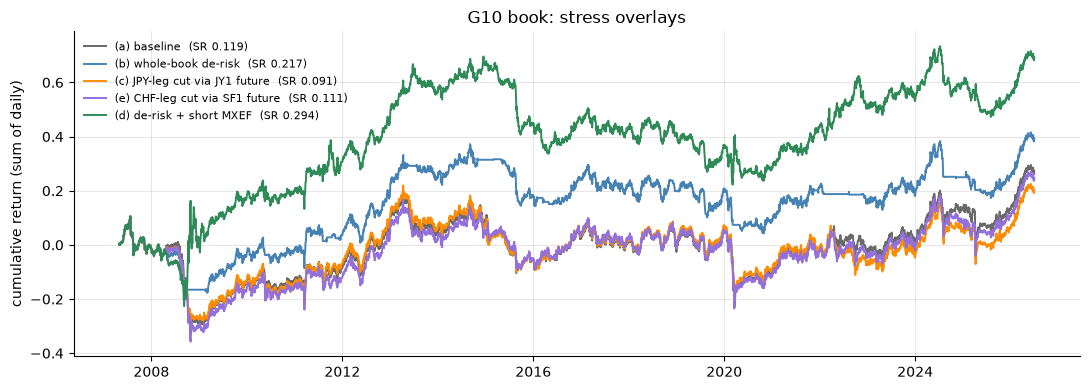

In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
prefix_styles = [("(a)", "dimgray"), ("(b)", "steelblue"), ("(c)", "darkorange"),
                 ("(e)", "mediumpurple"), ("(d)", "seagreen")]
for pfx, c in prefix_styles:
    k = next((k for k in scen_g10 if k.startswith(pfx + " ")), None)
    if k is None:
        continue
    ax.plot(scen_g10[k].index, scen_g10[k].cumsum().values, color=c, lw=1.4,
            label=f"{k}  (SR {sharpe(scen_g10[k]):.3f})")
ax.set_ylabel("cumulative return (sum of daily)")
ax.set_title("G10 book: stress overlays")
ax.legend(frameon=False, loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

## The answer: the crash risk is **not** in the funding legs — it is spread across the whole book

**This conclusion is unchanged by switching from the synthetic to the real futures.**

- Whole-book de-risking during stress nearly **doubles** the G10 Sharpe (0.119 → **0.217**): the
  book as a whole loses money on stress days (−1.2 bp/day vs +1.0 bp/day in calm markets).
- Cutting **only the JPY leg** during the same days makes things **worse**: 0.119 → **0.091** via
  JY1 futures, **0.068** via the spot+forward cross-check (the futures number is the flattered
  one — the roll-splice artifact adds non-earnable return to the long-JY1 overlay; the truth sits
  between, and both are below baseline). Flipping the leg long is worse still (0.059 via JY1).
- The **CHF leg tells the same story**: cutting it in stress gives 0.111 via SF1 futures, 0.077
  via the synthetic — below the 0.119 baseline either way. Cutting **both** funding legs at once
  (0.080) is no rescue. The funding shorts were not the source of the stress losses; in this
  sample they *earned* during high-FX-vol periods (JPY leg +1.2 bp/day with the trigger ON —
  the 2022–24 JPY depreciation ran through elevated FX vol, so the classic "JPY rallies in
  stress" pattern does not dominate this window).
- The best simple overlay remains replacing the book with a vol-matched **MXEF short** during
  stress (**0.294**) — an EM-equity crash hedge, which again points at broad risk appetite, not
  the funding currencies, as the book's stress factor. The DX1 version fails (−0.01): the carry
  sort is close to dollar-neutral, so the dollar index doesn't capture its stress exposure.
- Cross-check on the combined book agrees: JPY-leg cut 0.458 (JY1) / 0.447 (synthetic) and CHF-leg
  cut 0.468 / 0.451 against a 0.466 baseline — all roughly a wash — while whole-book de-risk
  helps (0.571).

**Conclusion:** the funding legs are not where the crash risk lives. Funding-currency hedging —
static (A.1), stress-triggered, via forwards or via listed futures (A.2) — subtracts compensated
legs without addressing the book's actual stress exposure, which is a broad risk-appetite factor
spread across all legs.

# Part B — Futures comparison table

Every hedge instrument vs the **combined baseline book** (committed ALL_net, Sharpe 0.466), on
each instrument's clean joined sample. With the 2026-08-03 pull, the funding-currency rows are the
**listed futures JY1 and SF1** — both classic funding currencies, not just JPY — with the
spot+forward replica demoted to a cross-check row; **SPXT** (S&P 500 total return) is the primary
S&P series and ES1 the cross-check. When those columns are absent, the table falls back to the
original six-instrument version. Per instrument:

- **corr** — full-sample correlation with book returns (post-join, post-stale-drop)
- **h\*** — variance-minimising static hedge ratio (OLS beta of book on instrument); hedged
  book = book − h\*·x. Plus the 252-day **rolling beta, lagged one day** (the honest
  implementable version) and the Sharpe of the dynamically hedged book using it.
- **Decomposition** — the Sharpe change is split into two separate columns:
  `d_sharpe_variance` (hedge with the instrument's own mean return stripped out — the pure
  variance-reduction effect) and `d_sharpe_own_ret` (what the instrument's own drift adds or
  costs). **A single blended Sharpe is never reported alone — that is what produced the earlier
  TLT false positive**, where most of the "hedging" gain was just Treasuries' own bull-market
  return.
- **NW t** — Newey–West HAC (5 lags) t-stat on the hedged-minus-unhedged daily return difference.
- **tail** — mean hedge payoff on the worst 5% of book days (bp/day).
- **Benchmark rule** — each hedged Sharpe is compared against the de-risking control on the same
  trigger (combined book: cut to zero in stress), not against the unhedged book.

**Two generic-series caveats, both exposed by the decomposition columns.** (1) UX1 is reported
twice: the generic front-month VIX future shows a large positive own return that is a roll-gap
splicing artifact no investor can earn; the investable `SPVXSTR` version bleeds heavily. (2) The
same mechanism, in milder form, inflates the JY1/SF1 generic series by ~200 bp/yr over the
forward replica (§1 cross-check) — so where a JY1/SF1 verdict differs from the replica's, trust
the replica's own-return level and treat the futures row's extra "return" as non-earnable.

Static overlay trading costs are ignored (futures half-spreads ~1 bp at near-constant notional);
the book side is net of FX trading costs.

In [12]:
INSTRUMENTS = {}
# funding-currency rows: listed futures are primary when present, replica demoted to cross-check
if r_jy1 is not None:
    INSTRUMENTS["JY1 (JPY future)"] = r_jy1
if r_sf1 is not None:
    INSTRUMENTS["SF1 (CHF future)"] = r_sf1
INSTRUMENTS["JPY_fwd (spot+fwd" + (", cross-check)" if r_jy1 is not None else ", long JPY)")] = r_jpyfwd
INSTRUMENTS["TU1 (UST 2y fut)"] = r_tu1
INSTRUMENTS["FV1 (UST 5y fut)"] = r_fv1
# S&P: total-return index is primary when present, ES1 demoted to cross-check
if sptr_hit is not None:
    root = sptr_hit[0].split()[0]
    r_sptr = clean_ret(sptr_hit[1], f"SPX_TR ({root})")
    INSTRUMENTS[f"SPX TR ({root})"] = r_sptr
    INSTRUMENTS["ES1 (S&P e-mini, cross-check)"] = r_es1
    print(f"S&P total-return index {sptr_hit[0]} found -> primary S&P series; ES1 kept as a cross-check.")
else:
    INSTRUMENTS["ES1 (S&P e-mini)"] = r_es1
    print("No S&P total-return index in the workbook -> ES1 futures are the TR stand-in "
          "(SPX price return would understate by ~dividend yield).")
INSTRUMENTS["DX1 (DXY fut)"] = r_dx1
INSTRUMENTS["UX1 (generic, NOT investable)"] = r_ux1
INSTRUMENTS["UX1 via SPVXSTR (investable)"] = r_vixtr

derisk_control = sharpe(all_book * (~trig_all))
rows = {}
for nm, x in INSTRUMENTS.items():
    idx = all_book.index.intersection(x.index)
    b, xi = all_book.loc[idx], x.loc[idx]
    h = b.cov(xi) / xi.var()                                   # variance-minimising ratio
    hedged   = b - h * xi
    var_only = b - h * (xi - xi.mean())                        # own drift stripped out
    roll_b = (b.rolling(252).cov(xi) / xi.rolling(252).var()).shift(1)   # 1-day lag
    dyn = (b - roll_b * xi).dropna()
    diff = -h * xi                                             # hedged minus unhedged
    nw = sm.OLS(diff.values, np.ones(len(diff))).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
    worst = b <= b.quantile(0.05)
    rows[nm] = {
        "n_clean": len(idx),
        "corr": b.corr(xi),
        "h_star": h,
        "roll_beta_mean": roll_b.mean(), "roll_beta_min": roll_b.min(), "roll_beta_max": roll_b.max(),
        "sharpe_book": sharpe(b),
        "sharpe_hedged": sharpe(hedged),
        "sharpe_dyn_hedged": sharpe(dyn),
        "d_sharpe_variance": sharpe(var_only) - sharpe(b),
        "d_sharpe_own_ret": sharpe(hedged) - sharpe(var_only),
        "hedge_own_ret_ann": -h * xi.mean() * fx.ANN_DAYS,
        "vol_reduction_pct": 100 * (1 - hedged.std() / b.std()),
        "nw_t_diff": nw.tvalues[0],
        "tail_mean_bp_worst5": diff[worst].mean() * 1e4,
        "inst_ann_ret": xi.mean() * fx.ANN_DAYS,
        "inst_sharpe": sharpe(xi),
        "derisk_control_sharpe": derisk_control,
        "beats_derisk_control": sharpe(hedged) > derisk_control,
    }

summary = pd.DataFrame(rows).T
summary.index.name = "instrument"
print(summary.round(3).to_string())
summary.to_csv(OUT / "hedge_comparison_summary.csv")
print("\nsaved ->", OUT / "hedge_comparison_summary.csv")

  SPX_TR (SPXT)  raw  5085 -> joined  4994 -> clean  4813  (180 stale zero-change rows dropped)
S&P total-return index SPXT Index found -> primary S&P series; ES1 kept as a cross-check.
                                n_clean      corr    h_star roll_beta_mean roll_beta_min roll_beta_max sharpe_book sharpe_hedged sharpe_dyn_hedged d_sharpe_variance d_sharpe_own_ret hedge_own_ret_ann vol_reduction_pct nw_t_diff tail_mean_bp_worst5 inst_ann_ret inst_sharpe derisk_control_sharpe beats_derisk_control
instrument                                                                                                                                                                                                                                                                                                                 
JY1 (JPY future)                   4794 -0.431627 -0.485304      -0.505613     -1.172193     -0.035721    0.436622       0.43192          0.364999           0.04741        -0.052112 

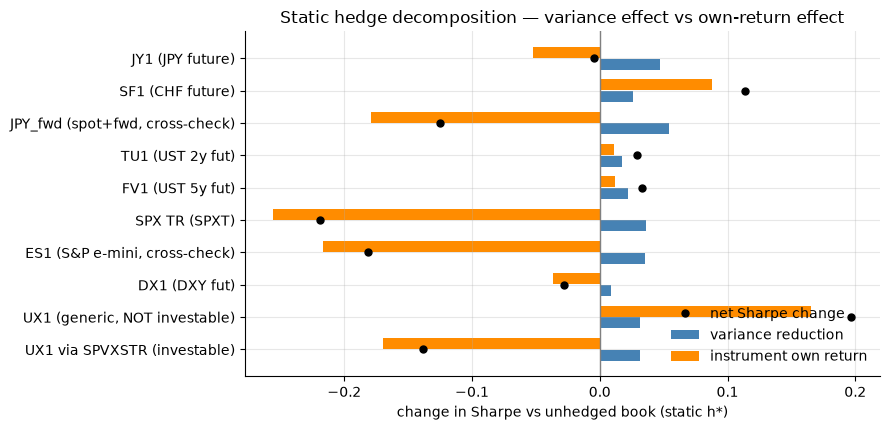

In [13]:
# decomposition chart: where does each hedged Sharpe come from?
plot_df = summary[["d_sharpe_variance", "d_sharpe_own_ret"]].astype(float)
y = np.arange(len(plot_df))
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.barh(y + 0.18, plot_df["d_sharpe_variance"], height=0.34, color="steelblue", label="variance reduction")
ax.barh(y - 0.18, plot_df["d_sharpe_own_ret"], height=0.34, color="darkorange", label="instrument own return")
tot = plot_df.sum(axis=1)
ax.plot(tot.values, y, "o", color="black", ms=5, label="net Sharpe change")
ax.axvline(0, color="gray", lw=1)
ax.set_yticks(y, plot_df.index)
ax.invert_yaxis()
ax.set_xlabel("change in Sharpe vs unhedged book (static h*)")
ax.set_title("Static hedge decomposition — variance effect vs own-return effect")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

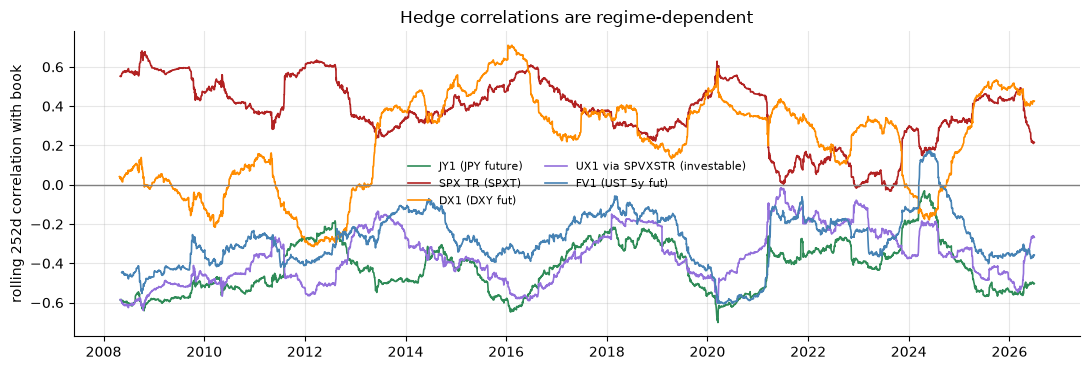

benchmark rule: de-risking control (combined book, stress exposure to zero) Sharpe = 0.571
                                sharpe_hedged beats_derisk_control
instrument                                                        
JY1 (JPY future)                      0.43192                False
SF1 (CHF future)                     0.576234                 True
JPY_fwd (spot+fwd, cross-check)      0.311156                False
TU1 (UST 2y fut)                     0.447748                False
FV1 (UST 5y fut)                     0.526256                False
SPX TR (SPXT)                        0.228616                False
ES1 (S&P e-mini, cross-check)        0.252895                False
DX1 (DXY fut)                         0.41873                False
UX1 (generic, NOT investable)        0.719861                 True
UX1 via SPVXSTR (investable)         0.314722                False


In [14]:
# rolling 252d correlation with the book (comparable scale across instruments)
PLOT_COLORS = {"JY1": "seagreen", "JPY_fwd": "seagreen", "SPX TR": "firebrick", "ES1": "firebrick",
               "DX1": "darkorange", "UX1 via SPVXSTR": "mediumpurple", "FV1": "steelblue"}
fig, ax = plt.subplots(figsize=(11, 3.8))
plotted = set()
for prefix, col in PLOT_COLORS.items():
    nm = next((k for k in INSTRUMENTS if k.startswith(prefix)), None)
    if nm is None or col in plotted:      # per color: first available series wins (futures/TR primary)
        continue
    plotted.add(col)
    x = INSTRUMENTS[nm]
    idx = all_book.index.intersection(x.index)
    rc = all_book.loc[idx].rolling(252).corr(x.loc[idx])
    ax.plot(rc.index, rc.values, color=col, lw=1.2, label=nm)
ax.axhline(0, color="gray", lw=1)
ax.set_ylabel("rolling 252d correlation with book")
ax.set_title("Hedge correlations are regime-dependent")
ax.legend(frameon=False, ncols=2, fontsize=8)
plt.tight_layout(); plt.show()

print(f"benchmark rule: de-risking control (combined book, stress exposure to zero) Sharpe = {derisk_control:.3f}")
verdict = summary[["sharpe_hedged", "beats_derisk_control"]].copy()
print(verdict.round(3).to_string())
if not verdict.loc[[i for i in verdict.index if "NOT investable" not in i], "beats_derisk_control"].any():
    print("\nNo investable instrument clears the de-risking bar.")

# Pros and cons by instrument

**JY1 (JPY future) / JPY via spot + 1M forward.** The funding-currency hedge, now measured on the
real contract with the forward replica as cross-check — and the pair is the same trade day to day
(correlation 0.94). It is the only instrument here that is a true crash hedge with the right sign
and meaningful size: book correlation −0.43/−0.46, and on the book's worst 5% of days the
variance-minimising long position pays **+32–34 bp/day**, the best tail payoff in the table. The
price is the negative carry: the replica shows the earnable cost honestly (own return −1.8%/yr,
blended Sharpe 0.44 → 0.31), while the JY1 row looks nearly free (0.44 → 0.43) only because the
generic series splices ~230 bp/yr of non-earnable roll jump into its history. Trust the replica's
cost, the futures' timing. Part A adds the sharper point: even used dynamically, cutting the JPY
leg in stress *hurt* this sample, on either implementation. Buy it if the mandate is drawdown
insurance — it is insurance at roughly actuarial price, not a Sharpe improvement.

**SF1 (CHF future).** The second classic funding currency, and a weaker version of the JPY story:
right-sign correlation (−0.32), decent tail payoff (+17 bp/day), smaller variance reduction. Its
headline result — hedged Sharpe 0.576, the one investable row that nominally beats the de-risk
control (0.571) — should **not** be trusted at face value: the margin is three parts per
thousand of Sharpe, and the SF1 generic series carries the same ~207 bp/yr roll-splice inflation;
priced off the CHF forward replica the hedge lands at 0.469 and the "beat" disappears. CHF's own
carry is also less negative than JPY's, so the position bleeds less but protects less. A
reasonable diversifier of the funding hedge, not a free lunch — and Part A shows cutting the CHF
leg in stress hurts the book just like the JPY leg.

**TU1 / FV1 (Treasury front-end futures).** The benign middle ground. Correlation is negative
(−0.28 / −0.29), so the hedge is a *long* duration position, and in this sample the front-end
futures had essentially zero own drift — the decomposition shows the small Sharpe changes are
almost pure variance effect, which is exactly what an honest hedge should look like (and what the
TLT analysis, conflating duration's bull-market return with hedging, got wrong). The problem is
size: betas per unit of futures-price vol are huge and unstable (TU1's rolling beta spans −9.6 to
+0.8) because the instruments barely move, vol reduction is only ~4%, and the tail payoff
(~16 bp/day) is half of JPY's. Cheap, harmless, stabilising — and too weak to change the book's
risk profile on its own. The 2022 failure mode (hiking into risk-off) applies with less severity
than for long duration.

**SPXT (S&P 500 total return) / ES1 (cross-check).** The wrong-way hedge, now measured on the
true total-return series. The book is *positively* correlated with equities (+0.38), so the
variance-minimising position is short — and with dividends properly counted the short sells the
full equity premium at −2.7%/yr (vs −2.3%/yr on ES1, which embeds dividends only via futures
pricing), dragging the Sharpe from 0.45 to 0.23, the worst static result in the table and the
most significant (NW t = −3.1). ES1 as cross-check agrees (0.43 → 0.25). The tail payoff
(+26 bp/day) is real, which is why the stress-*conditional* EM-equity short in Part A works — as
a triggered overlay, not a static one.

**DX1 (DXY future).** The false friend. Headline correlation is small (+0.19), the beta is
unstable and sign-flipping (rolling −0.42 to +1.45), the tail payoff is trivial (+5 bp/day), and
the static hedge is a wash (0.45 → 0.42). The structural reason, established in the earlier DXY
work, still holds: a carry sort is close to dollar-neutral by construction, and DXY is a
EUR-bloc index with no EM content, so it can't see the book's actual stress exposure. Both the
static hedge here and the stress-triggered version in Part A fail. Not a hedge for this book.

**UX1 (VIX futures).** The table's built-in cautionary tale. On the raw generic front-month
series, a long-vol overlay looks like the best thing in the table (hedged Sharpe 0.72, beats
even the de-risk control) — but that rests on a **+46%/yr "own return" that is a roll-gap
artifact of generic-contract splicing and cannot be earned**. Priced off the investable SPVXSTR
roll, the same position *bleeds* −33%/yr, and the hedged Sharpe is 0.32. What is genuine: the
correlation is the most reliably negative in the set (−0.35, negative in essentially every
regime) and the tail payoff (+27 bp/day) is second only to JPY. Long VIX futures are real crash
insurance sold at a steep, persistent premium — affordable only in small size, sized off the
SPVXSTR numbers, never the generic series. The JY1/SF1 rows above carry a mild dose of exactly
this disease; UX1 is the full-blown case.

**Bottom line.** Judged by the benchmark rule — beat simple de-risking (Sharpe 0.57 on the
combined book with this trigger) — **no investable futures overlay genuinely qualifies**: the two
rows that nominally clear the bar are the non-investable UX1 generic (by a mile, on a pure
artifact) and SF1 (by 0.005, which vanishes on the artifact-free replica). The honest ranking of
what each instrument buys: JPY/CHF funding hedges and VIX futures are real but fully-priced crash
insurance, front-end Treasuries are cheap-but-weak stabilisers, a static S&P short is anti-hedge,
DX1 is noise. Risk management for this book is better done by conditioning exposure (de-risking,
or the triggered EM-equity short) than by any always-on futures hedge.